## Dependencia temporal

**Objetivo:** medir o quanto a serie depende dos seus proprios valores passados. Isso ajuda a responder se existe memoria curta, padrao semanal e recorrencia anual.

Nesta etapa vamos analisar:
- **ACF** para medir a autocorrelacao em diferentes lags;
- **PACF** para identificar defasagens com dependencia mais direta;
- **lag plots** para visualizar a relacao entre a serie atual e seus atrasos;
- uma tabela de correlacao nas defasagens **t-1**, **t-7**, **t-14**, **t-30** e **t-365**.

Como a serie tem tendencia forte, e esperado que a ACF da serie bruta fique elevada em varios lags. Ainda assim, esse bloco e util para mostrar a memoria temporal observada da serie.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.parquet"

df_internacoes = pd.read_parquet(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

# Dependencia temporal

In [3]:
serie_dependencia = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_dependencia = int(serie_dependencia.isna().sum())
if faltantes_dependencia > 0:
    print(f"Foram encontrados {faltantes_dependencia} dias faltantes. A serie sera interpolada para a analise de dependencia temporal.")
    serie_dependencia = serie_dependencia.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a analise de dependencia temporal.")

lags_interesse = [1, 7, 14, 30, 365]
df_lags = pd.DataFrame(index=serie_dependencia.index)
df_lags["num_internacoes"] = serie_dependencia

for lag in lags_interesse:
    df_lags[f"lag_{lag}"] = serie_dependencia.shift(lag)

display(df_lags.head(10))

Nenhum dia faltante foi encontrado para a analise de dependencia temporal.


,num_internacoes,lag_1,lag_7,lag_14,lag_30,lag_365
data_dia,,,,,,
2008-01-01,79,NaN,NaN,NaN,NaN,NaN
2008-01-02,46,79.0,NaN,NaN,NaN,NaN
2008-01-03,53,46.0,NaN,NaN,NaN,NaN
2008-01-04,46,53.0,NaN,NaN,NaN,NaN
2008-01-05,42,46.0,NaN,NaN,NaN,NaN
2008-01-06,28,42.0,NaN,NaN,NaN,NaN
2008-01-07,36,28.0,NaN,NaN,NaN,NaN
2008-01-08,50,36.0,79.0,NaN,NaN,NaN
2008-01-09,39,50.0,46.0,NaN,NaN,NaN


### ACF e PACF

A **ACF** mostra a persistencia global da serie ao longo das defasagens. A **PACF** ajuda a destacar quais lags ainda guardam informacao mais direta depois de controlar os anteriores.

Usamos dois alcances diferentes na ACF:
- um recorte curto, para enxergar a memoria imediata;
- um recorte mais longo, para verificar sinais de padrao semanal e anual.

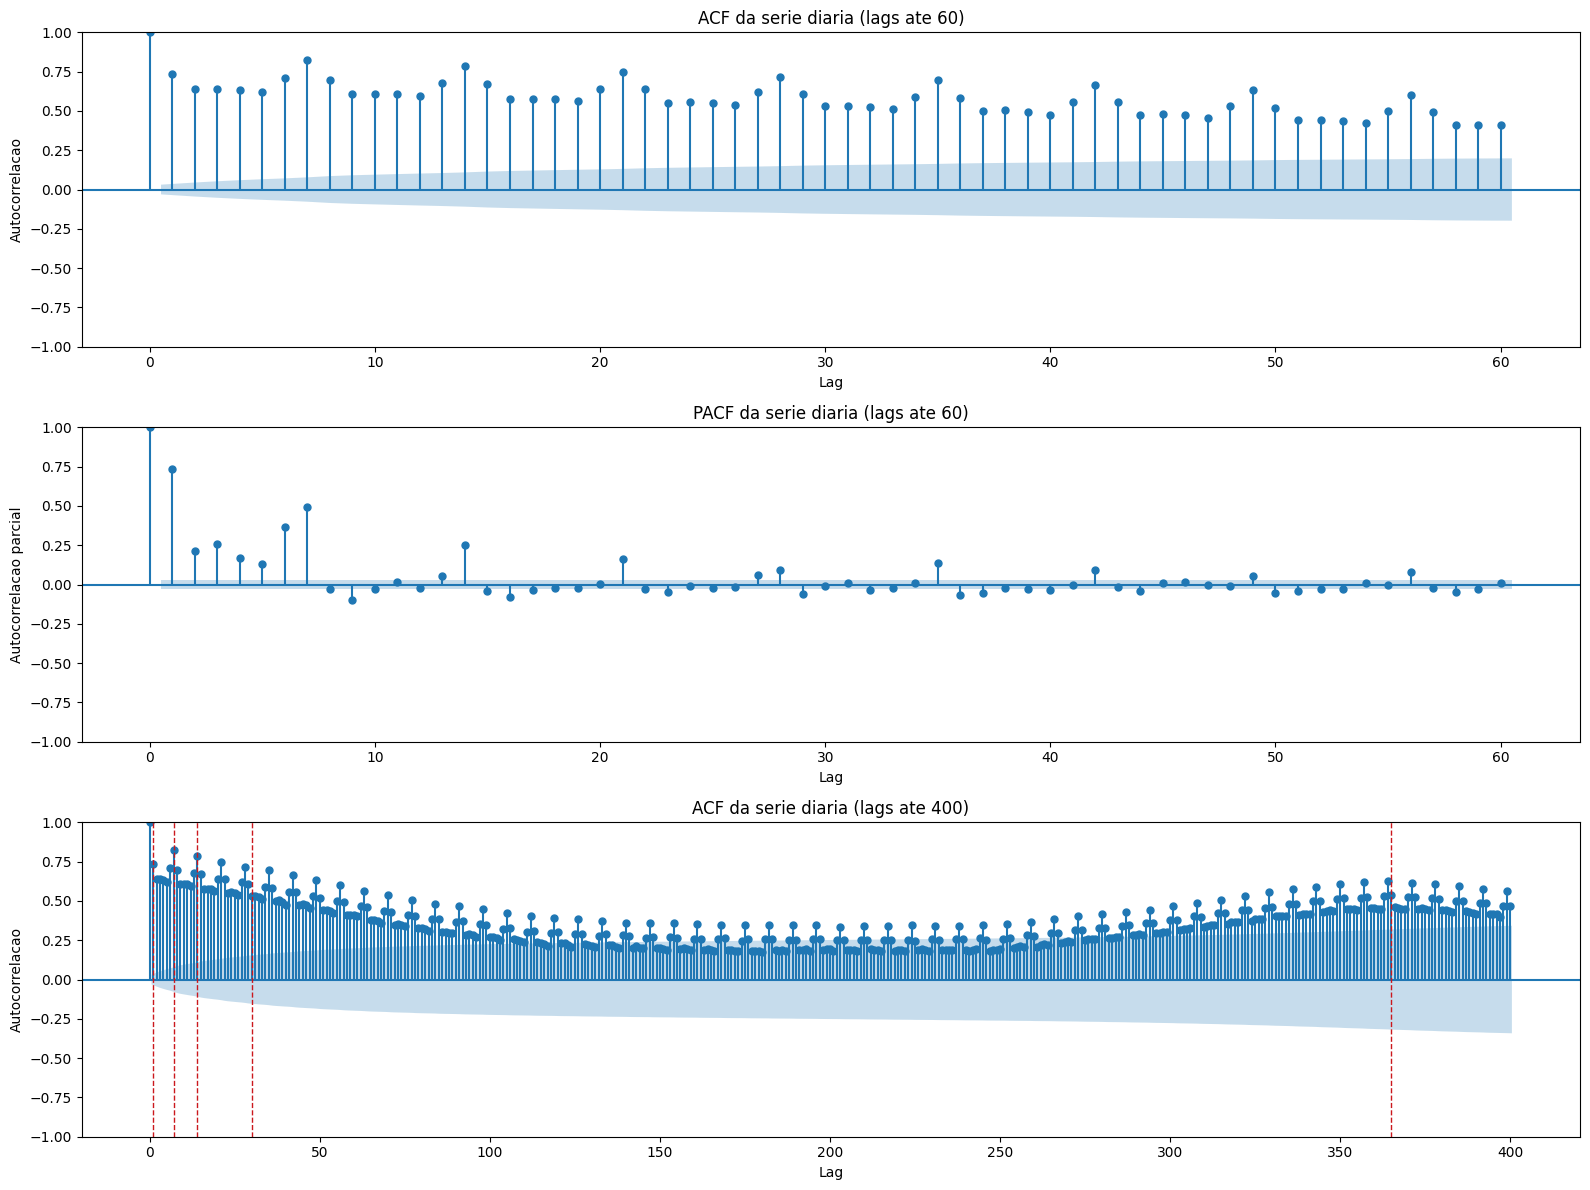

In [4]:
lags_acf_curto = 60
lags_acf_longo = 400
lags_pacf = 60

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

plot_acf(serie_dependencia, lags=lags_acf_curto, ax=axes[0], alpha=0.05, fft=True)
axes[0].set_title("ACF da serie diaria (lags ate 60)")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelacao")

plot_pacf(serie_dependencia, lags=lags_pacf, ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF da serie diaria (lags ate 60)")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelacao parcial")

plot_acf(serie_dependencia, lags=lags_acf_longo, ax=axes[2], alpha=0.05, fft=True)
axes[2].set_title("ACF da serie diaria (lags ate 400)")
axes[2].set_xlabel("Lag")
axes[2].set_ylabel("Autocorrelacao")

for lag_marcado in lags_interesse:
    if lag_marcado <= lags_acf_longo:
        axes[2].axvline(lag_marcado, color="#cb181d", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

### Lag plots

Os lag plots mostram a relacao entre o valor atual da serie e um valor atrasado. Quanto mais alinhados e concentrados os pontos em torno de uma diagonal crescente, maior tende a ser a dependencia temporal naquele lag.

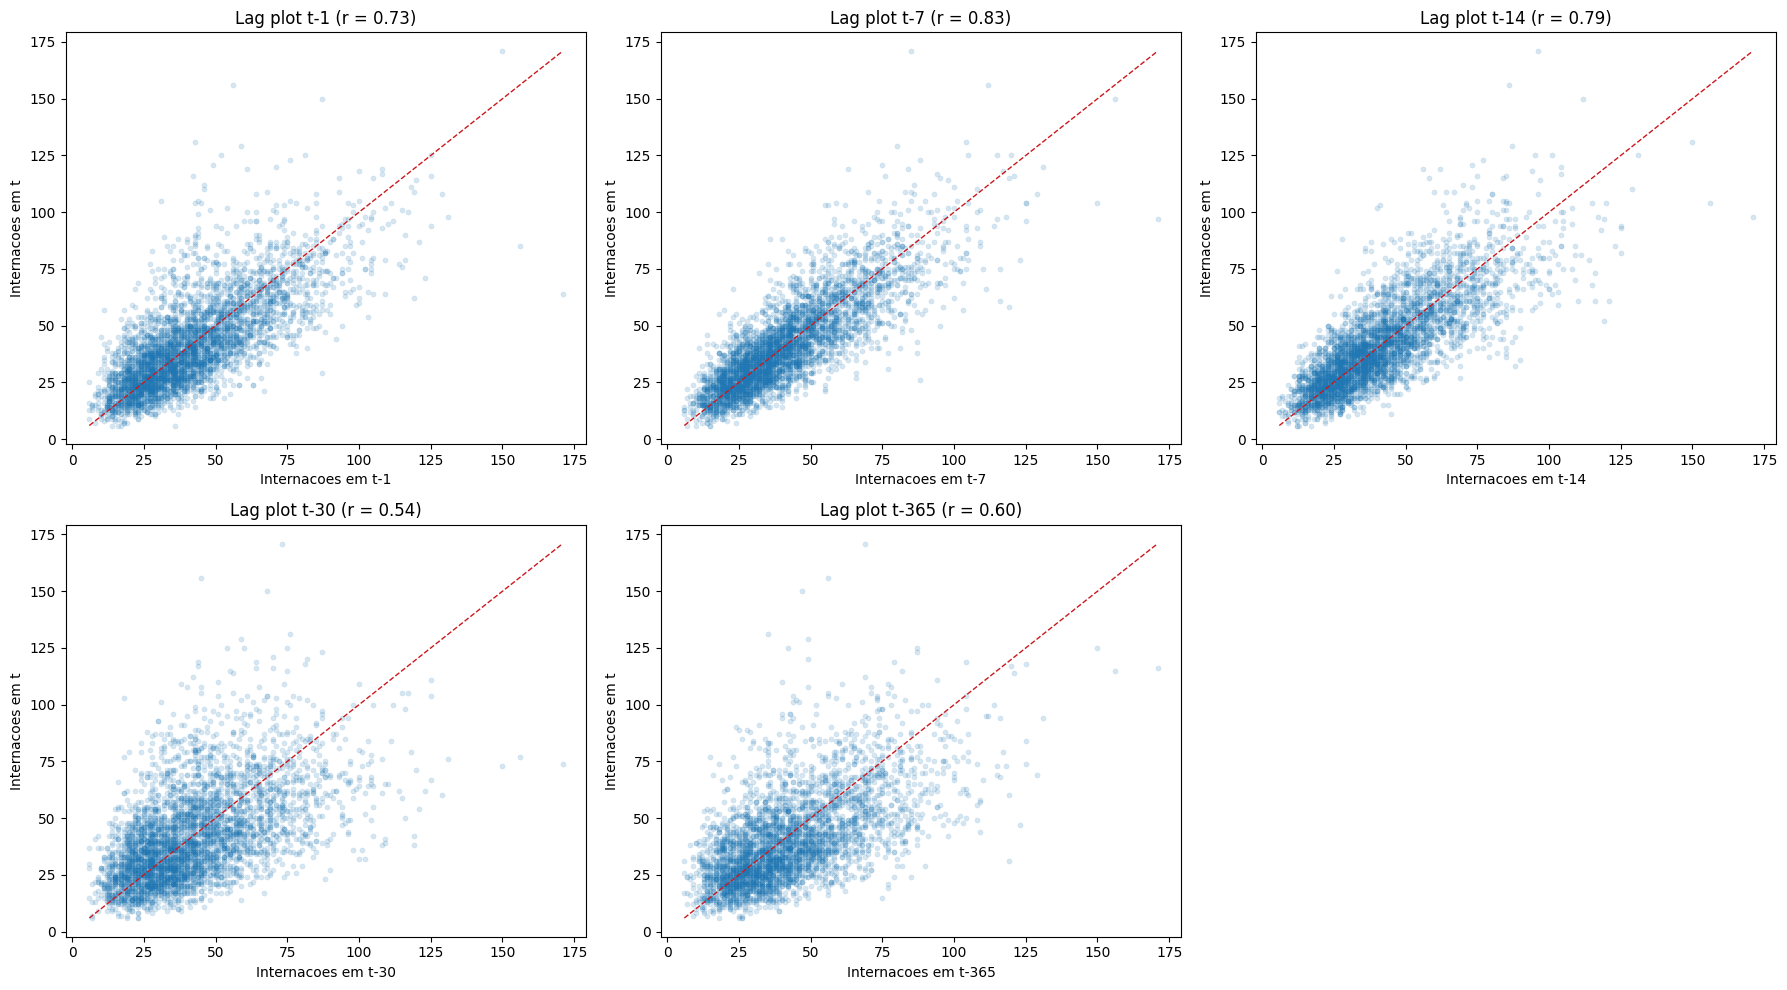

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, lag in enumerate(lags_interesse):
    dados_plot = df_lags[["num_internacoes", f"lag_{lag}"]].dropna()
    correlacao_lag = dados_plot["num_internacoes"].corr(dados_plot[f"lag_{lag}"])

    sns.scatterplot(
        data=dados_plot,
        x=f"lag_{lag}",
        y="num_internacoes",
        alpha=0.18,
        s=14,
        edgecolor=None,
        ax=axes[i],
    )

    menor_valor = min(dados_plot["num_internacoes"].min(), dados_plot[f"lag_{lag}"].min())
    maior_valor = max(dados_plot["num_internacoes"].max(), dados_plot[f"lag_{lag}"].max())
    axes[i].plot([menor_valor, maior_valor], [menor_valor, maior_valor], color="#cb181d", linestyle="--", linewidth=1)
    axes[i].set_title(f"Lag plot t-{lag} (r = {correlacao_lag:.2f})")
    axes[i].set_xlabel(f"Internacoes em t-{lag}")
    axes[i].set_ylabel("Internacoes em t")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Correlacao nas defasagens de interesse

Esta tabela resume a forca da dependencia temporal nos lags mais relevantes para a serie. Alem da correlacao de Pearson entre `t` e `t-k`, tambem registramos o valor correspondente da ACF para o mesmo lag.

,lag,correlacao_pearson,autocorrelacao_acf,n_observacoes
0,1,0.735,0.734,4017
1,7,0.826,0.825,4011
2,14,0.788,0.786,4004
3,30,0.536,0.533,3988
4,365,0.596,0.538,3653


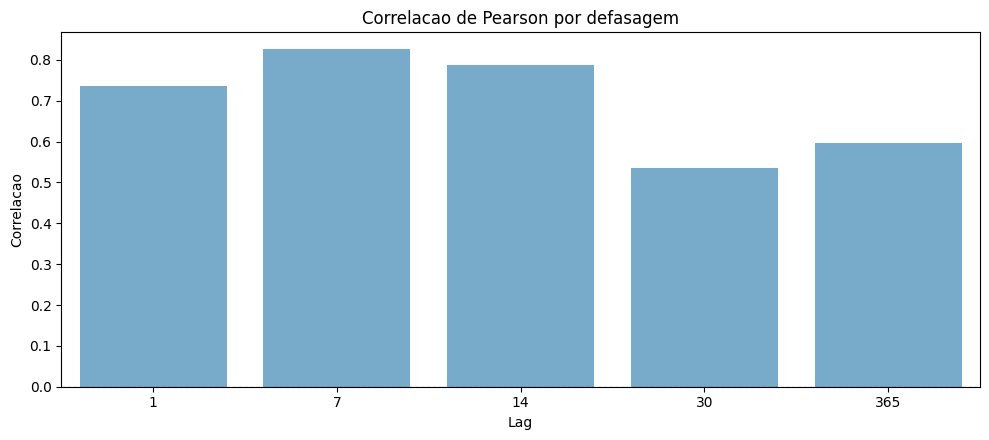

In [6]:
acf_valores = acf(serie_dependencia, nlags=max(lags_interesse), fft=True)

resumo_lags = []
for lag in lags_interesse:
    dados_lag = df_lags[["num_internacoes", f"lag_{lag}"]].dropna()
    resumo_lags.append(
        {
            "lag": lag,
            "correlacao_pearson": dados_lag["num_internacoes"].corr(dados_lag[f"lag_{lag}"]),
            "autocorrelacao_acf": acf_valores[lag],
            "n_observacoes": len(dados_lag),
        }
    )

resumo_lags = pd.DataFrame(resumo_lags)
display(resumo_lags.round(3))

plt.figure(figsize=(10, 4.5))
sns.barplot(data=resumo_lags, x="lag", y="correlacao_pearson", color="#6baed6")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Correlacao de Pearson por defasagem")
plt.xlabel("Lag")
plt.ylabel("Correlacao")
plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

A análise de dependência temporal mostrou novamente **persistência forte no curto prazo** e **padrão semanal muito marcado**. A correlação em **t-1** permaneceu alta (**0,741**), mas a maior relação apareceu em **t-7 (0,825)**, seguida de **t-14 (0,797)**. Isso indica que o valor observado uma semana antes segue explicando a série atual com mais força do que o dia imediatamente anterior.

A **ACF** confirmou esse comportamento. Além de permanecer elevada nos primeiros lags, ela exibiu picos claros em múltiplos de 7, com destaque para **lag 7 (0,822)** e **lag 14 (0,793)**, padrão típico de **recorrência semanal consistente**. Esse resultado é coerente com os achados de sazonalidade e decomposição.

A **PACF** reforça essa leitura ao manter o maior efeito direto no **lag 1**, com sinais visuais relevantes também em defasagens associadas ao ciclo semanal. Em termos práticos, mesmo controlando os atrasos mais curtos, ainda existe informação adicional em lags ligados ao calendário semanal.

Em horizontes mais longos, a dependência permanece, mas enfraquece gradualmente. A correlação em **t-30** ainda foi relevante (**0,579**; ACF **0,573**), e em **t-365** ficou em patamar moderado (**0,540** na correlação de Pearson e **0,392** na ACF). Isso sugere recorrência anual presente, porém menos intensa que a memória curta e semanal.

Outro ponto importante é que a ACF decai de forma relativamente lenta, inclusive em lags mais longos. Isso é compatível com a evidência anterior de tendência e sazonalidade fortes, indicando que a série bruta provavelmente não é estacionária em nível. Assim, parte da autocorrelação observada reflete não apenas memória temporal, mas também estrutura de calendário e mudança de nível.

**Possíveis análises e consequências**
- Os lags **1**, **7** e **14** seguem como candidatos prioritários para features em modelos de previsão.
- O sinal ainda presente em **30 dias** sugere incluir memória de médio prazo (lags ou janelas móveis).
- O lag **365** pode entrar como complemento para recorrência anual, com peso menor que os lags curtos e semanais.
- Como a ACF da série bruta permanece alta por bastante tempo, vale repetir a análise em versões diferenciadas/detrendadas/dessazonalizadas para separar memória real de não estacionariedade.
- A combinação de memória curta forte com padrão semanal claro favorece modelos autorregressivos com lags explícitos e features de calendário.